# Analise exploratoria - Historicos multivar

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## 1. Matriz de correlação

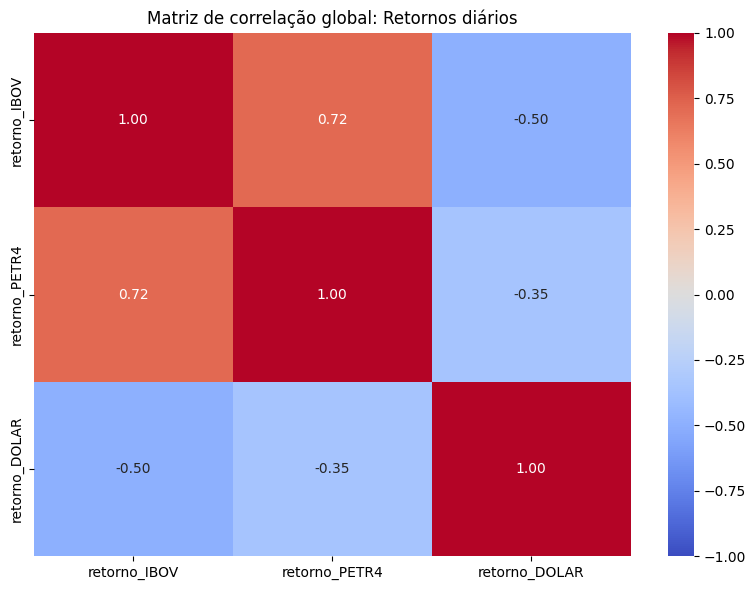

In [67]:
df_ibov = pd.read_csv('dados/ibov_multivar.csv', parse_dates=['date'])
# df_itub = pd.read_csv('dados/itub4_multivar.csv')
df_petr = pd.read_csv('dados/petr4_multivar.csv', parse_dates=['date'])
df_dolar = pd.read_csv('dados/dolar_multivar.csv', parse_dates=['date'])
df_ibov_r = df_ibov[['date', 'return']].rename(columns={'return': 'retorno_IBOV'})
#df_itub_r = df_itub[['date', 'return']].rename(columns={'return': 'retorno_ITUB4'})
df_petr_r = df_petr[['date', 'return']].rename(columns={'return': 'retorno_PETR4'})
df_dolar_r = df_dolar[['date', 'return']].rename(columns={'return': 'retorno_DOLAR'})

#df_unif = pd.merge(df_ibov_r, df_itub_r, on='date', how='inner')
#df_unif = pd.merge(df_unif, df_petr_r, on='date', how='inner')
df_unif = pd.merge(df_ibov_r, df_petr_r, on='date', how='inner')
df_unif = pd.merge(df_unif, df_dolar_r, on='date', how='inner')

# gerando a matriz de correlação
#cols = ['retorno_IBOV', 'retorno_ITUB4', 'retorno_PETR4', 'retorno_DOLAR']
cols = ['retorno_IBOV', 'retorno_PETR4', 'retorno_DOLAR']
mat_corr = df_unif[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(mat_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlação global: Retornos diários')
plt.tight_layout()
plt.show()

In [ ]:
#df_unif = pd.merge(df_ibov_r, df_itub_r, on='date', how='inner')
#df_unif = pd.merge(df_unif, df_petr_r, on='date', how='inner')
df_unif = pd.merge(df_ibov_r, df_petr_r, on='date', how='inner')
df_unif = pd.merge(df_unif, df_dolar_r, on='date', how='inner')

# data > 29/05/2024
df_unif = df_unif[df_unif['date'] > '2024-05-29']

# gerando a matriz de correlação
#cols = ['retorno_IBOV', 'retorno_ITUB4', 'retorno_PETR4', 'retorno_DOLAR']
cols = ['retorno_IBOV', 'retorno_PETR4', 'retorno_DOLAR']
mat_corr = df_unif[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(mat_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlação global: Retornos diários')
plt.tight_layout()
plt.show()

In [68]:
print('--- df_dolar ---')
display(df_dolar.head())
display(df_dolar.tail())

display(df_dolar.describe())

--- df_dolar ---


,date,open,high,low,closed,return
0,2010-01-05,1.722,1.732,1.718,1.731,0.006395
1,2010-01-06,1.734,1.739,1.728,1.739,0.004622
2,2010-01-07,1.740,1.749,1.738,1.745,0.003450
3,2010-01-08,1.749,1.752,1.728,1.730,-0.008596
4,2010-01-11,1.722,1.740,1.717,1.736,0.003468


,date,open,high,low,closed,return
4114,2026-05-25,5.0103,5.0222,4.9952,5.0217,-0.000915
4115,2026-05-26,5.0167,5.0391,5.0046,5.0310,0.001852
4116,2026-05-27,5.0360,5.0720,5.0320,5.0585,0.005466
4117,2026-05-28,5.0585,5.0756,5.0245,5.0315,-0.005338
4118,2026-05-29,5.0315,5.0722,5.0315,5.0478,0.003240


,date,open,high,low,closed,return
count,4119,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,2018-03-18 16:29:01.005098,3.736975,3.761388,3.714593,3.737554,0.000304
min,2010-01-05 00:00:00,1.532000,1.539000,1.530000,1.538000,-0.053048
25%,2014-02-03 12:00:00,2.267500,2.278500,2.258000,2.269000,-0.005065
50%,2018-03-16 00:00:00,3.748000,3.773000,3.726000,3.750000,0.000000
75%,2022-05-03 12:00:00,5.170100,5.208500,5.137500,5.168000,0.005527
max,2026-05-29 00:00:00,6.247500,6.300500,6.192300,6.248000,0.085842
std,NaN,1.412661,1.423798,1.401597,1.412183,0.009271


## 2. Historico retornos diarios

In [69]:
# convertendo data
# df_unif['date'] = pd.to_datetime(df_unif['date'])

# 
# cores = ['red', 'blue']
# cols_retorno = ['retorno_ITUB4', 'retorno_PETR4']

# 
# Criando figura interativa com plotly
# fig = go.Figure()

# 
# for col, cor in zip(cols_retorno, cores):
    # fig.add_trace(go.Scatter(
        # x=df_unif['date'],
        # y=df_unif[col],
        # mode='lines',
        # name=col.replace('retorno_', ''),
        # line=dict(color=cor, width=2),
        # opacity=0.5
    # ))

# 
# fig.update_layout(
    # title='Histórico de retornos diários',
    # xaxis_title='Data',
    # yaxis_title='Retorno',
    # hovermode='x unified',
    # template='plotly_white',
    # height=500,
    # width=1000
# )

# 
# fig.show()

In [70]:
# convertendo data
df_unif['date'] = pd.to_datetime(df_unif['date'])

cores = ['red', 'blue']
cols_retorno = ['retorno_IBOV', 'retorno_DOLAR']

# Criando figura interativa com plotly
fig = go.Figure()

for col, cor in zip(cols_retorno, cores):
    fig.add_trace(go.Scatter(
        x=df_unif['date'],
        y=df_unif[col],
        mode='lines',
        name=col.replace('retorno_', ''),
        line=dict(color=cor, width=2),
        opacity=0.5
    ))

fig.update_layout(
    title='Histórico de retornos diários',
    xaxis_title='Data',
    yaxis_title='Retorno',
    hovermode='x unified',
    template='plotly_white',
    height=500,
    width=1000
)

fig.show()

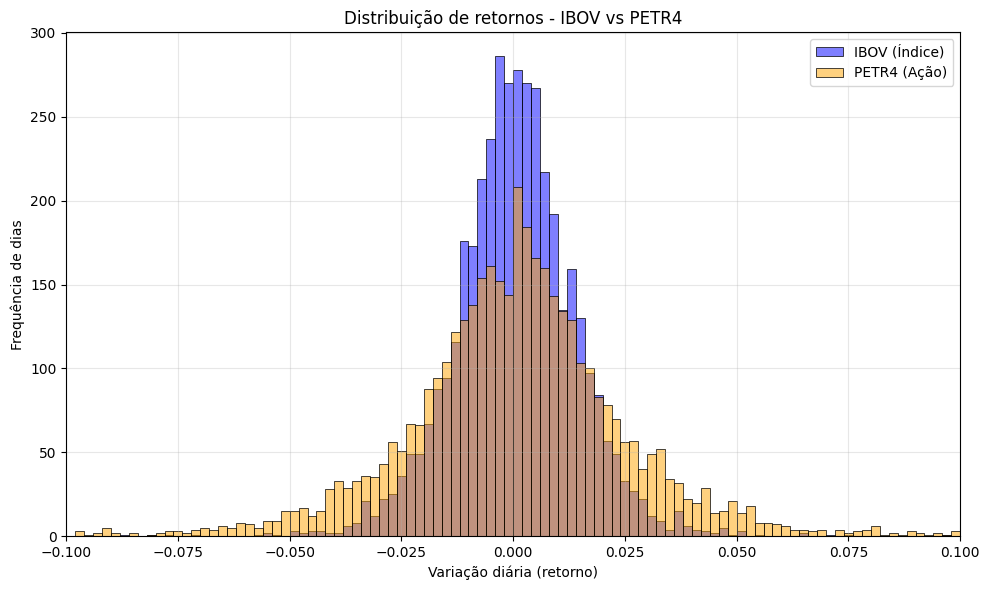

In [71]:
plt.figure(figsize=(10, 6))
sns.histplot(df_ibov['return'].dropna(), bins=100, color='blue', alpha=0.5, label='IBOV (Índice)', binrange=(-0.1, 0.1))
sns.histplot(df_petr['return'].dropna(), bins=100, color='orange', alpha=0.5, label='PETR4 (Ação)', binrange=(-0.1, 0.1))

plt.title('Distribuição de retornos - IBOV vs PETR4')
plt.xlabel('Variação diária (retorno)')
plt.ylabel('Frequência de dias')
plt.xlim(-0.1, 0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
# plt.figure(figsize=(10, 6))
# sns.histplot(df_ibov['return'].dropna(), bins=100, color='blue', alpha=0.5, label='IBOV (Índice)')
# sns.histplot(df_itub['return'].dropna(), bins=100, color='orange', alpha=0.5, label='ITUB4 (Ação)')

# 
# plt.title('Distribuição de retornos: IBOV vs ITUB4')
# plt.xlabel('Variação diária (retorno)')
# plt.ylabel('Frequência de dias')
# plt.xlim(-0.1, 0.1)
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

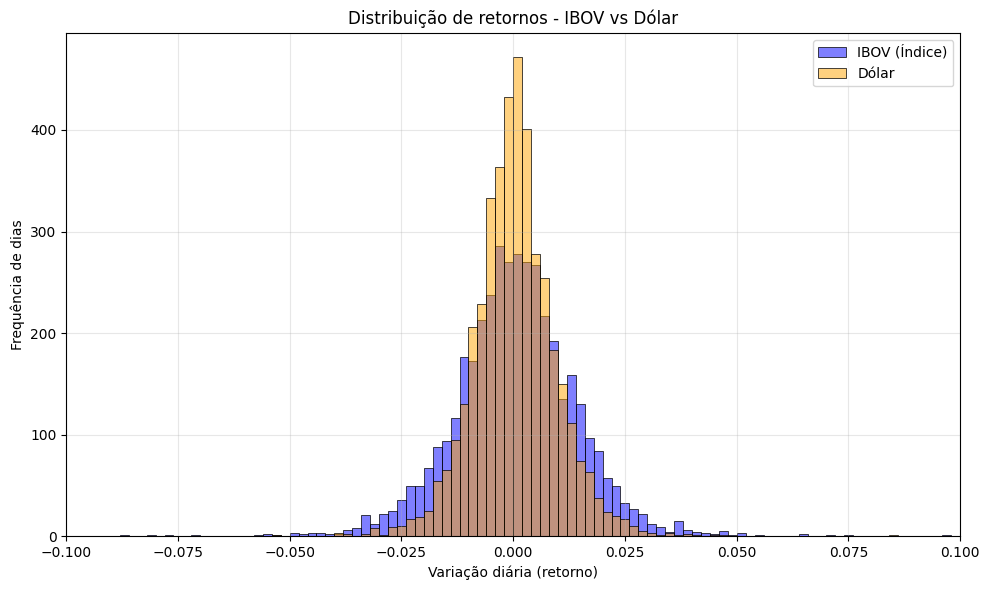

In [73]:
plt.figure(figsize=(10, 6))
sns.histplot(df_ibov['return'].dropna(), bins=100, color='blue', alpha=0.5, label='IBOV (Índice)', binrange=(-0.1, 0.1))
sns.histplot(df_dolar['return'].dropna(), bins=100, color='orange', alpha=0.5, label='Dólar', binrange=(-0.1, 0.1))

plt.title('Distribuição de retornos - IBOV vs Dólar')
plt.xlabel('Variação diária (retorno)')
plt.ylabel('Frequência de dias')
plt.xlim(-0.1, 0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
# plt.figure(figsize=(10, 6))
# sns.histplot(df_itub['return'].dropna(), bins=100, color='blue', alpha=0.5, label='ITUB4')
# sns.histplot(df_petr['return'].dropna(), bins=100, color='orange', alpha=0.5, label='PETR4')

# 
# plt.title('Distribuição de retornos: ITUB4 vs PETR4')
# plt.xlabel('Variação diária (retorno)')
# plt.ylabel('Frequência de dias')
# plt.xlim(-0.1, 0.1)
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

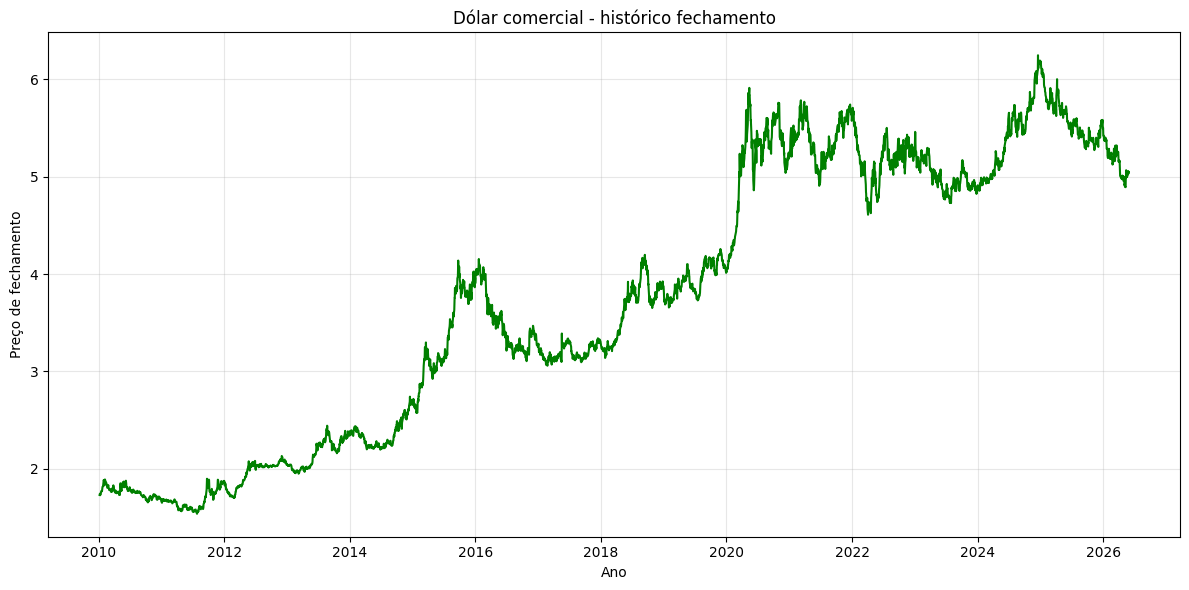

In [75]:
plt.figure(figsize=(12, 6))
plt.plot(df_dolar['date'], df_dolar['closed'], color='green', linewidth=1.5)

plt.title('Dólar comercial - histórico fechamento')
plt.xlabel('Ano')
plt.ylabel('Preço de fechamento')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

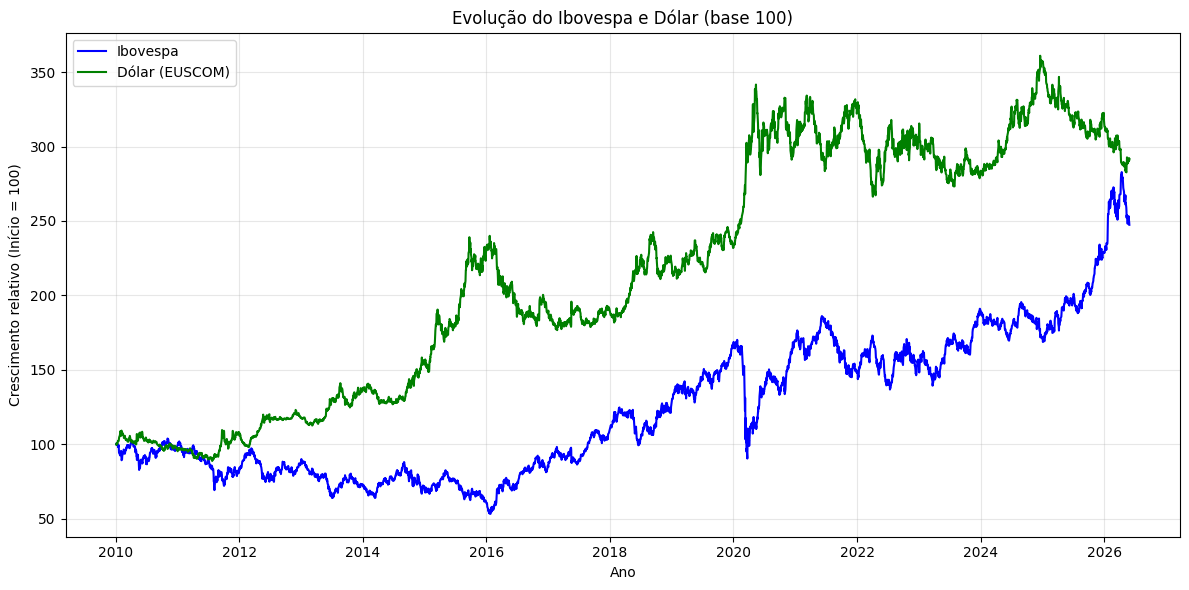

In [76]:
df_ibov_c = df_ibov[['date', 'closed']].rename(columns={'closed': 'IBOV'})
df_dolar_c = df_dolar[['date', 'closed']].rename(columns={'closed': 'DOLAR'})

df_unif = pd.merge(df_ibov_c, df_dolar_c, on='date', how='inner')
df_unif['date'] = pd.to_datetime(df_unif['date'])

# normalização: (Preço atual / Preço do dia 1) * 100
df_unif['IBOV_Norm'] = (df_unif['IBOV'] / df_unif['IBOV'][0]) * 100
df_unif['DOLAR_Norm'] = (df_unif['DOLAR'] / df_unif['DOLAR'][0]) * 100

plt.figure(figsize=(12, 6))
plt.plot(df_unif['date'], df_unif['IBOV_Norm'], label='Ibovespa', color='blue', linewidth=1.5)
plt.plot(df_unif['date'], df_unif['DOLAR_Norm'], label='Dólar (EUSCOM)', color='green', linewidth=1.5)

plt.title('Evolução do Ibovespa e Dólar (base 100)')
plt.xlabel('Ano')
plt.ylabel('Crescimento relativo (Início = 100)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Gráficos candlestick

In [77]:
# últimos 60 dias para melhor visualização
df_60 = df_petr.tail(60).copy()

# preço em cima e volume embaixo
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.03, row_heights=[0.7, 0.3])

# candlestick na linha 1
fig.add_trace(go.Candlestick(
    x=df_60['date'],
    open=df_60['open'], high=df_60['high'],
    low=df_60['low'], close=df_60['closed'],
    name='OHLC'
), row=1, col=1)

# colorindo o volume de verde (dia de alta) ou vermelho (dia de baixa)
cores_vol = ['green' if close >= open else 'red' 
                for close, open in zip(df_60['closed'], df_60['open'])]

# volume na linha 2
fig.add_trace(go.Bar(
    x=df_60['date'], y=df_60['vol'],
    marker_color=cores_vol, name='Volume'
), row=2, col=1)

fig.update_layout(
    title='PETR4: Preço e volume',
    xaxis_rangeslider_visible=False,
    template='plotly_white',
    height=600
)
fig.show()

In [78]:
# últimos 60 dias para melhor visualização
# df_60 = df_itub.tail(60).copy()

# 
# preço em cima e volume embaixo
# fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    # vertical_spacing=0.03, row_heights=[0.7, 0.3])

# 
# candlestick na linha 1
# fig.add_trace(go.Candlestick(
    # x=df_60['date'],
    # open=df_60['open'], high=df_60['high'],
    # low=df_60['low'], close=df_60['closed'],
    # name='OHLC'
# ), row=1, col=1)

# 
# colorindo o volume de verde (dia de alta) ou vermelho (dia de baixa)
# cores_vol = ['green' if close >= open else 'red' 
                # for close, open in zip(df_60['closed'], df_60['open'])]

# 
# volume na linha 2
# fig.add_trace(go.Bar(
    # x=df_60['date'], y=df_60['vol'],
    # marker_color=cores_vol, name='Volume'
# ), row=2, col=1)

# 
# fig.update_layout(
    # title='ITUB4: Preço e volume',
    # xaxis_rangeslider_visible=False,
    # template='plotly_white',
    # height=600
# )
# fig.show()